In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from data_preprocessing import load_dataset

dataset_easy = load_dataset("E4A-C_1-1.data")
dataset_medium = load_dataset("E4A-C_2-8.data")
dataset_hard = load_dataset("E4A-C_9-64.data")

Dataset E4A-C_1-1.data cargado con 2200 muestras.
Dataset E4A-C_2-8.data cargado con 2200 muestras.
Dataset E4A-C_9-64.data cargado con 2200 muestras.


In [3]:
from models.CLPTransformer_v4 import CLPTransformer

# Parámetros del modelo
blocks_dim = 8
action_dim = 2
placed_dim = 4
space_dim = 6
d_model = 32
nhead = 4
num_layers = 2
dropout = 0.1

# Crear modelo
model = CLPTransformer(
    block_dim=blocks_dim,
    action_dim=action_dim,
    placed_dim=placed_dim,
    space_dim=space_dim,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout
)

In [4]:
from training import train

epochs = 100
datasets = [dataset_hard, dataset_medium, dataset_easy]
train_size = 1800
train_weights = [1, 1, 1]
test_size = 400
test_weights = [1, 1, 1]
batch_size = 32
learning_rate = 1e-4
seed = 42

stats = train(model, epochs, datasets, train_size, train_weights, test_size, test_weights, batch_size, learning_rate, seed)

ℹ️ Usando dispositivo: cpu
ℹ️ Iniciando fase: 1/3


/home/oscar/CLP-Framework/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/100 - Train Loss: 4.1708, Train Accuracy: 1.78% - Val Loss: 4.1574, Val Accuracy: 3.01%
    Test Set: E4A-C_9-64.data - Val Loss: 4.1574, Val Accuracy: 3.01%
    Test Set: E4A-C_2-8.data - Val Loss: 4.1613, Val Accuracy: 1.50%
    Test Set: E4A-C_1-1.data - Val Loss: 4.1640, Val Accuracy: 0.00%
    Weighted - Val Loss: 4.1609, Val Accuracy: 1.50%
Epoch 2/100 - Train Loss: 4.1575, Train Accuracy: 1.83% - Val Loss: 4.1541, Val Accuracy: 8.27%
    Test Set: E4A-C_9-64.data - Val Loss: 4.1541, Val Accuracy: 8.27%
    Test Set: E4A-C_2-8.data - Val Loss: 4.1623, Val Accuracy: 0.00%
    Test Set: E4A-C_1-1.data - Val Loss: 4.1676, Val Accuracy: 0.00%
    Weighted - Val Loss: 4.1614, Val Accuracy: 2.76%
Epoch 3/100 - Train Loss: 4.1512, Train Accuracy: 1.94% - Val Loss: 4.1498, Val Accuracy: 6.77%
    Test Set: E4A-C_9-64.data - Val Loss: 4.1498, Val Accuracy: 6.77%
    Test Set: E4A-C_2-8.data - Val Loss: 4.1647, Val Accuracy: 0.00%
    Test Set: E4A-C_1-1.data - Val Loss: 4.1749, Va

KeyboardInterrupt: 

In [10]:
from training import save_model

model_name = "CLPTransformer_v2_ACL"
save_model(model, model_name)

✅ Modelo guardado en /home/oscar/CLP-Framework/models/CLPTransformer_v2_ACL.pth


In [6]:
from training import load_model

model = load_model(CLPTransformer, model_name)

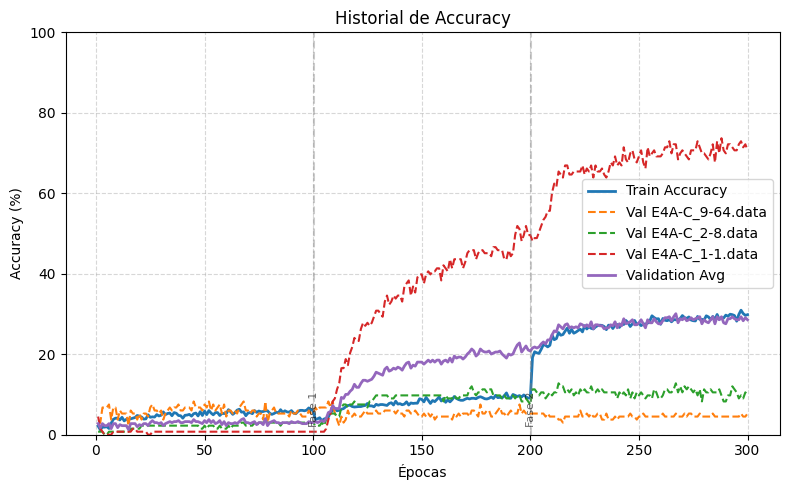

In [7]:
stats.plot()